# Students Performance Analysis

## 1. Setup

In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

## 2. Data Loading & Initial Inspection

In [181]:
students_performance = pd.read_csv('../data/StudentsPerformance.csv')

display(students_performance.head())
print(f"Dataset Shape: {students_performance.shape}\n")

print("Data Info:")
students_performance.info()

print("\nMissing Values:")
print(students_performance.isnull().sum())

print(f"\nDuplicate Rows: {students_performance.duplicated().sum()}")

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Dataset Shape: (1000, 8)

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score 

In [182]:
students_performance.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [183]:
students_performance['gender'] = students_performance['gender'].map({'female': 0, 'male': 1})
students_performance['lunch'] = students_performance['lunch'].map({'free/reduced': 0, 'standard': 1})
students_performance['test preparation course'] = students_performance['test preparation course'].map({'none': 0, 'completed': 1})

education_mapping = {
    'some high school': 0,
    'high school': 1,
    'some college': 2,
    "associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree": 5
}
students_performance['parental level of education'] = students_performance['parental level of education'].map(education_mapping)

students_performance = pd.get_dummies(students_performance, columns=['race/ethnicity'], drop_first=True)

students_performance

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,0,4,1,0,72,72,74,True,False,False,False
1,0,2,1,1,69,90,88,False,True,False,False
2,0,5,1,0,90,95,93,True,False,False,False
3,1,3,0,0,47,57,44,False,False,False,False
4,1,2,1,0,76,78,75,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
995,0,5,1,1,88,99,95,False,False,False,True
996,1,1,0,0,62,55,55,False,True,False,False
997,0,1,0,1,59,71,65,False,True,False,False
998,0,2,1,1,68,78,77,False,False,True,False


## 3. Exploratory Data Analysis (EDA)

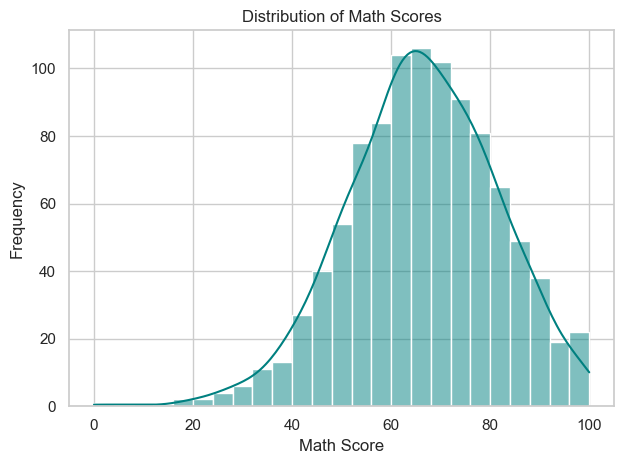

In [184]:
sns.histplot(students_performance['math score'], color='teal', kde=True)
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../outputs/math_score_distribution.png', dpi=150)
plt.show()

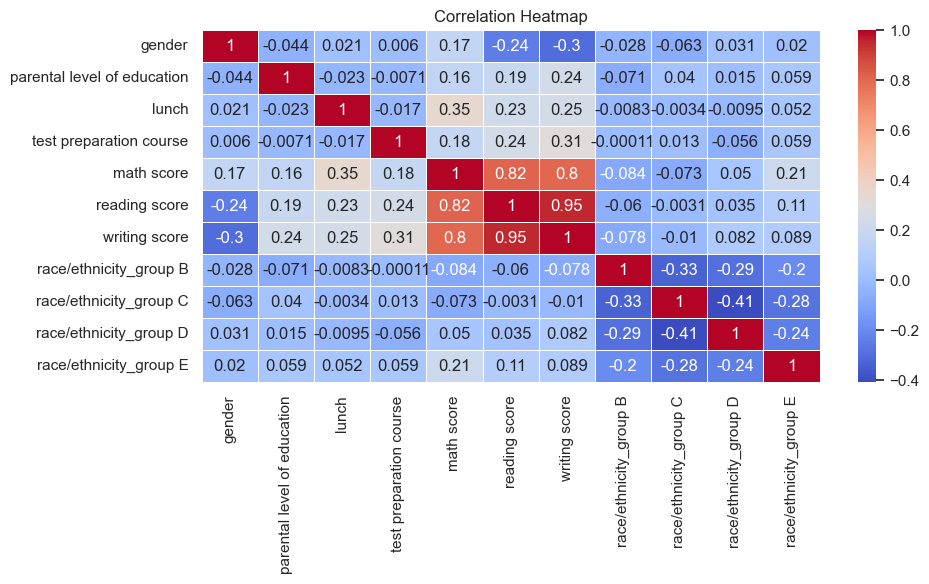

In [185]:
plt.figure(figsize=(10, 6))
sns.heatmap(students_performance.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()

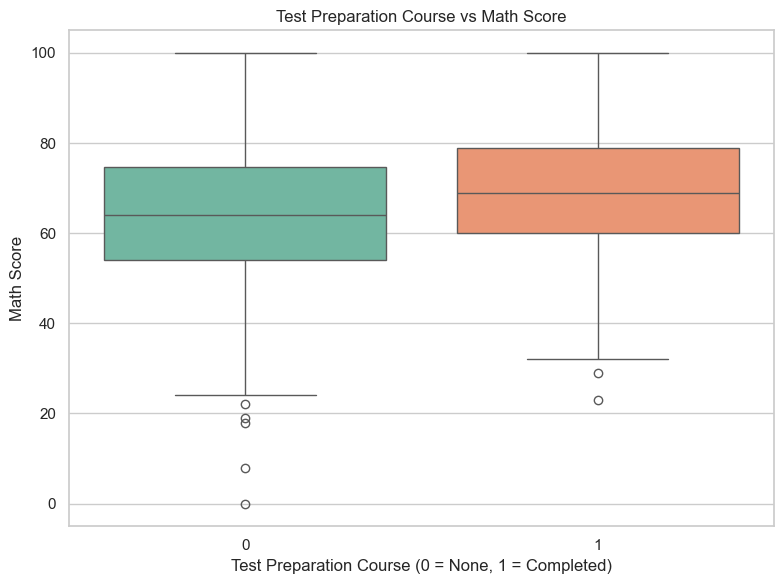

In [186]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='test preparation course', y='math score', data=students_performance, palette='Set2')
plt.title('Test Preparation Course vs Math Score')
plt.xlabel('Test Preparation Course (0 = None, 1 = Completed)')
plt.ylabel('Math Score')
plt.tight_layout()
plt.savefig('../outputs/boxplot_test_prep.png', dpi=150)
plt.show()

### EDA Key Insights:
* **Target Distribution:** The math scores form a normal distribution. The most frequent scores fall between 64-68, with 90%+ of students scoring between 40-100.
* **Strong Predictors:** `reading score` (0.82) and `writing score` (0.80) are highly correlated with the target. However, they are also highly correlated with *each other*, indicating multicollinearity. 
* **Moderate Predictors:** `lunch` has a moderate positive correlation (0.35).
* **Weak Predictors:** `gender`, `race/ethnicity`, `test preparation course`, and `parental level of education` show weaker linear relationships (below 0.20).
* **Outliers Detected:** The boxplot reveals extreme low-score outliers that could skew our Linear Regression line of best fit.

## 4. Outlier Removal (IQR Method)

In [187]:
Q1 = students_performance['math score'].quantile(0.25)
Q3 = students_performance['math score'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

clean_data = students_performance[
    (students_performance['math score'] >= lower_bound) & 
    (students_performance['math score'] <= upper_bound)
]

print(f"Original rows: {len(students_performance)}")
print(f"Clean rows: {len(clean_data)}")

Original rows: 1000
Clean rows: 992


## 5. Model Training & Evaluation (Cleaned & Scaled Data)

In [188]:
y_clean = clean_data['math score']
# Dropping writing score to reduce multicollinearity
# reading score is kept as it has slightly higher correlation with math score
X_clean = clean_data.drop(['math score', 'writing score'], axis=1)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

scaled_model = LinearRegression()
scaled_model.fit(X_train_scaled, y_train_c)

scaled_predictions = scaled_model.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test_c, scaled_predictions)
mse_lr = mean_squared_error(y_test_c, scaled_predictions)
r2_lr = r2_score(y_test_c, scaled_predictions)
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"R-squared: {r2_lr:.4f}")

Mean Absolute Error (MAE): 4.7309
Mean Squared Error (MSE): 35.0513
R-squared: 0.8468


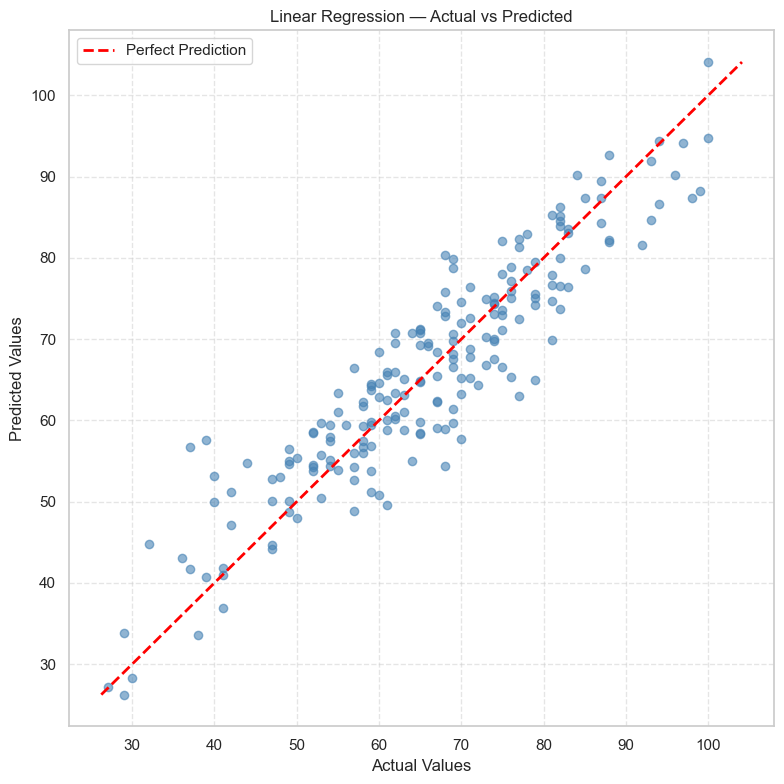

In [189]:
plt.figure(figsize = (8, 8))
plt.scatter(y_test_c, scaled_predictions, color = 'steelblue', alpha=0.6)
min_val = min(min(y_test_c), min(scaled_predictions))
max_val = max(max(y_test_c), max(scaled_predictions))
plt.plot([min_val, max_val], [min_val, max_val], color = 'red', linestyle = '--', linewidth = 2, label = 'Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression — Actual vs Predicted')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../outputs/lr_actual_vs_predicted.png', dpi=150)
plt.show()

## 6. Feature Importance

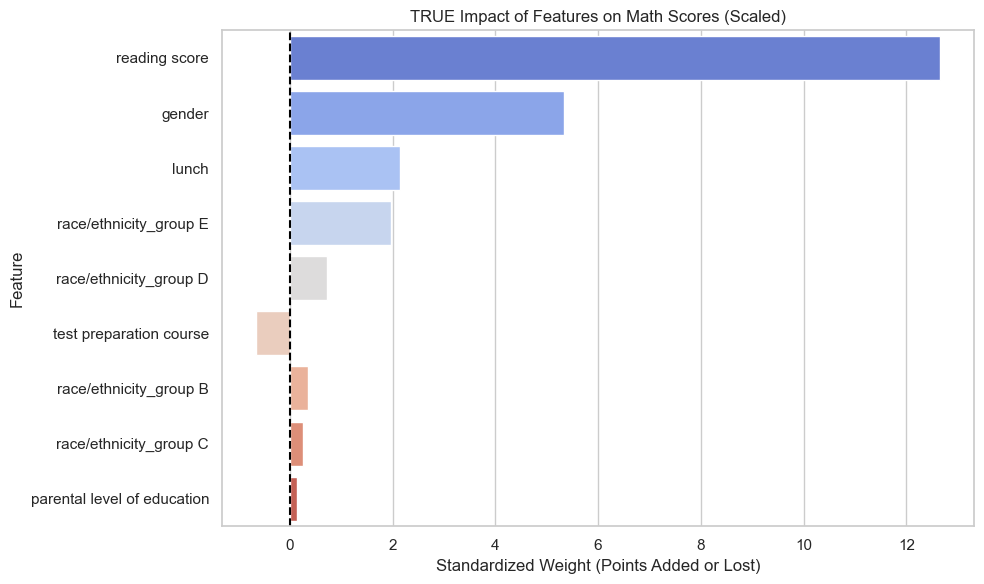

In [190]:
scaled_coefficients = scaled_model.coef_
feature_names = X_clean.columns

scaled_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': scaled_coefficients
})

scaled_importance['Absolute_Importance'] = scaled_importance['Importance'].abs()
scaled_importance = scaled_importance.sort_values(by='Absolute_Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=scaled_importance, x='Importance', y='Feature', palette='coolwarm')
plt.title('TRUE Impact of Features on Math Scores (Scaled)')
plt.xlabel('Standardized Weight (Points Added or Lost)')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig('../outputs/lr_feature_importance.png', dpi=150)
plt.show()

## 7. Random Forest Regression

In [191]:
import warnings
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')

In [192]:
# Dropping writing score to reduce multicollinearity
# reading score is kept as it has slightly higher correlation with math score
X_rfr = clean_data.drop(columns = ['math score', 'writing score'])
print(f"Features for Random Forest: {X_rfr.columns.tolist()}")
print(f"Feature Data Types:\n{X_rfr.dtypes}\n")
y_rfr = clean_data['math score']
X_train_rfr, X_test_rfr, y_train_rfr, y_test_rfr = train_test_split(X_rfr, y_rfr, test_size = 0.2, random_state = 42)
rfr_model = RandomForestRegressor(n_estimators = 100, random_state = 42, oob_score=True, bootstrap=True)
rfr_model.fit(X_train_rfr, y_train_rfr)
print("Out-of-Bag Score:", rfr_model.oob_score_)
rfr_predictions = rfr_model.predict(X_test_rfr)
mae_rfr = mean_absolute_error(y_test_rfr, rfr_predictions)
mse_rfr = mean_squared_error(y_test_rfr, rfr_predictions)
r2_rfr = r2_score(y_test_rfr, rfr_predictions)
print(f"Random Forest Regressor Model Completed")
print(f"Random Forest Mean Absolute Error (MAE): {mae_rfr:.4f}")
print(f"Random Forest Mean Squared Error (MSE): {mse_rfr:.4f}")
print(f"Random Forest R-squared: {r2_rfr:.4f}")

Features for Random Forest: ['gender', 'parental level of education', 'lunch', 'test preparation course', 'reading score', 'race/ethnicity_group B', 'race/ethnicity_group C', 'race/ethnicity_group D', 'race/ethnicity_group E']
Feature Data Types:
gender                         int64
parental level of education    int64
lunch                          int64
test preparation course        int64
reading score                  int64
race/ethnicity_group B          bool
race/ethnicity_group C          bool
race/ethnicity_group D          bool
race/ethnicity_group E          bool
dtype: object

Out-of-Bag Score: 0.7654644857885851
Random Forest Regressor Model Completed
Random Forest Mean Absolute Error (MAE): 5.5889
Random Forest Mean Squared Error (MSE): 48.8464
Random Forest R-squared: 0.7866


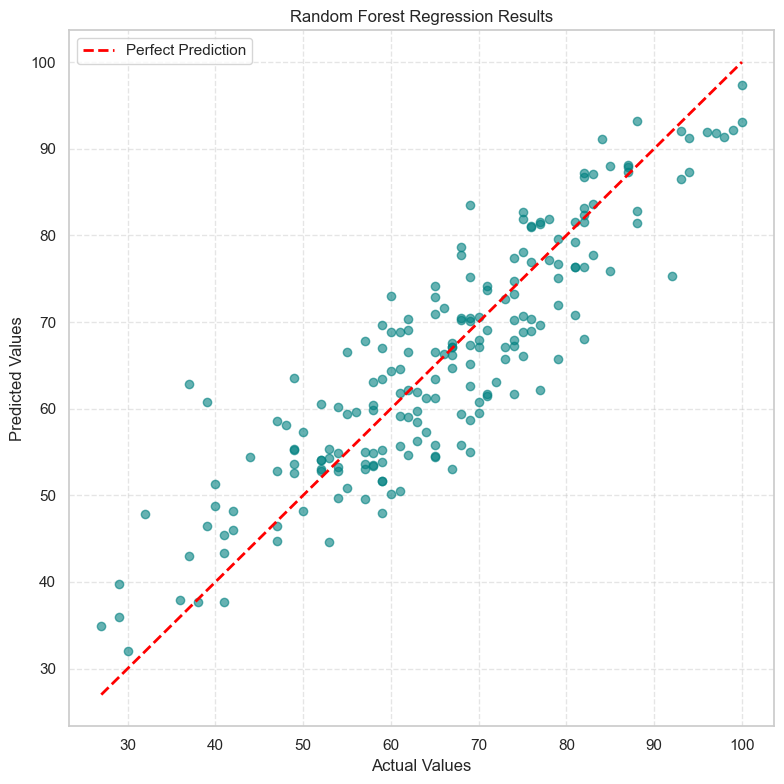

In [193]:
plt.figure(figsize = (8, 8))
plt.scatter(y_test_rfr, rfr_predictions, color = 'teal', alpha = 0.6)
min_val = min(min(y_test_rfr), min(rfr_predictions))
max_val = max(max(y_test_rfr), max(rfr_predictions))
plt.plot([min_val, max_val], [min_val, max_val], color = 'red', linestyle = '--', linewidth = 2, label = 'Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest Regression Results')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../outputs/rfr_actual_vs_predicted.png', dpi=150)
plt.show()

## 8. Random Forest Feature Importance

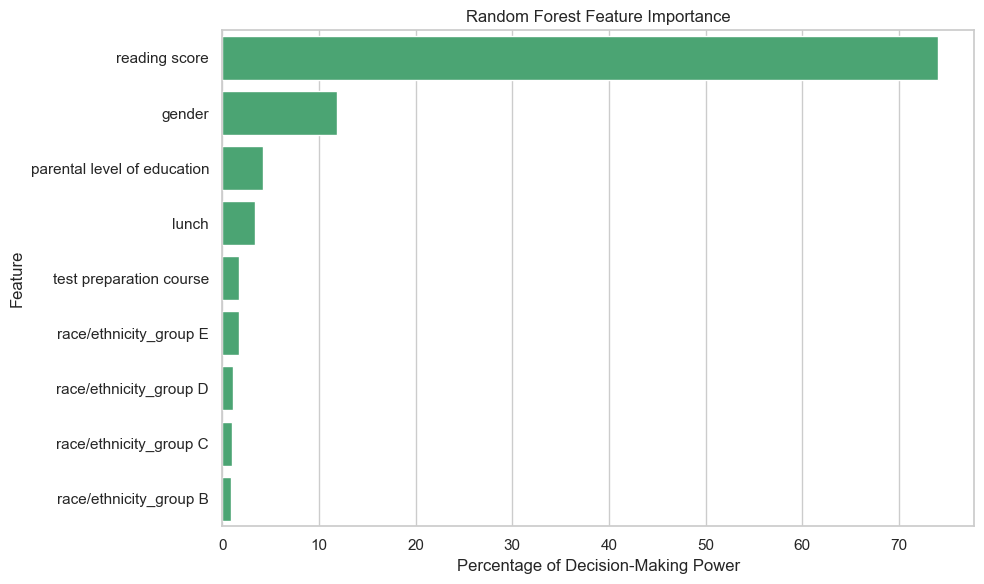

,Feature,Importance (%)
4,reading score,74.06
0,gender,11.88
1,parental level of education,4.19
2,lunch,3.34
3,test preparation course,1.78
8,race/ethnicity_group E,1.75
7,race/ethnicity_group D,1.08
6,race/ethnicity_group C,1.04
5,race/ethnicity_group B,0.88


In [194]:
rf_importances = rfr_model.feature_importances_

rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (%)': rf_importances * 100
})

rf_importance_df = rf_importance_df.sort_values(by='Importance (%)', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance_df, x='Importance (%)', y='Feature', color='mediumseagreen')
plt.title("Random Forest Feature Importance")
plt.xlabel("Percentage of Decision-Making Power")
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../outputs/rf_feature_importance.png', dpi=150)
plt.show()

display(rf_importance_df.round(2))

## 9. Model comparison summary table

In [195]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [mae_lr, mae_rfr],
    'MSE': [mse_lr, mse_rfr],
    'R² Score': [r2_lr, r2_rfr]
})
print(comparison.to_string(index=False))

                  Model      MAE       MSE  R² Score
      Linear Regression 4.730935 35.051296  0.846836
Random Forest Regressor 5.588892 48.846352  0.786555
